# RM Copilot — Evaluation Notebook

Part B Analytics aligned with Horizon documents:
- **Product guides:** PG-002 (HCIF), PG-003 (HAEF), PG-004
- **Compliance:** CMP-002, CMP-003
- **Research:** RN-001, RN-002

Run `python scripts/ingest.py` before evaluating.

In [1]:
import sys
import json
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

import pandas as pd
import matplotlib.pyplot as plt

from src.evaluation.metrics import run_all_evaluations

## Run All Evaluations

In [2]:
report = run_all_evaluations()
summary_keys = ['retrieval', 'citation_coverage', 'suitability_gate', 'escalation', 'entitlement', 'single_vs_multi_hop', 'faithfulness', 'agent_scenarios']
for key in summary_keys:
    val = report[key]
    if isinstance(val, dict) and 'details' in val:
        val = {k: v for k, v in val.items() if k != 'details'}
    print(f"{key}: {val}")

C:\Users\Alia\Downloads\capstone-boa\src\ingestion\indexer.py:66: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  return Chroma(


retrieval: {'retrieval_hit_rate': 0.8571428571428571}
citation_coverage: {'citation_coverage': 1.0, 'total_chunks': 31, 'with_citations': 31}
suitability_gate: {'suitability_precision': 1.0}
escalation: {'escalation_detection_rate': 1.0}
entitlement: {'restricted_leaked_to_unentitled': 0, 'restricted_available_to_entitled': 10, 'cmp002_visible_unentitled': 0, 'cmp002_visible_entitled': 10, 'filter_working': True}
single_vs_multi_hop: {'single_shot_count': 5, 'multi_hop_count': 5, 'unique_docs_single': 2, 'unique_docs_multi': 2, 'multi_hop_gain': 0, 'single_doc_ids': ['PG-002', 'RN-001'], 'multi_doc_ids': ['PG-002', 'RN-001']}


## 1. Retrieval Relevance (golden set)

In [3]:
retrieval_df = pd.DataFrame(report['retrieval']['details'])
print(f"Hit Rate: {report['retrieval']['retrieval_hit_rate']:.1%}")
retrieval_df

Hit Rate: 85.7%


,query,retrieved,expected_ids,retrieved_ids,relevant_hit
0,Prepare talking points for client C-204's quar...,5,"[PG-002, RN-001, CMP-003]","[RN-002, RN-001, RN-001, RN-001, PG-002]",True
1,Is PG-003 suitable for a conservative client?,5,"[PG-003, CMP-003]","[PG-002, PG-002, RN-001, PG-003, PG-003]",True
2,Is PG-002 suitable for a conservative client?,5,[PG-002],"[PG-002, RN-001, PG-002, PG-003, PG-002]",True
3,Summarize the portfolio risk for client C-204,5,[],"[RN-001, PG-002, PG-003, PG-003, PG-003]",True
4,Recommend a personalized 4% withdrawal rate fo...,5,[],"[PG-002, PG-002, PG-003, CMP-003, RN-002]",True
5,What are the restricted concentration limit ru...,1,[CMP-002],[RN-002],False
6,What are the latest technology and AI sector i...,5,[RN-002],"[RN-002, RN-002, RN-002, RN-002, RN-002]",True


## 2. Citation Coverage

In [4]:
cov = report['citation_coverage']
print(f"Citation Coverage: {cov['citation_coverage']:.1%}")
print(f"Chunks with citations: {cov['with_citations']}/{cov['total_chunks']}")

Citation Coverage: 100.0%
Chunks with citations: 31/31


## 3. Suitability Gate (PG-002 / PG-003 / PG-004)

In [5]:
suit_df = pd.DataFrame(report['suitability_gate']['details'])
print(f"Precision: {report['suitability_gate']['suitability_precision']:.1%}")
suit_df

Precision: 100.0%


,fund,profile,expected,actual,correct
0,PG-003,Conservative,False,False,True
1,HAEF,Conservative,False,False,True
2,PG-002,Conservative,True,True,True
3,HCIF,Conservative,True,True,True
4,PG-004,Balanced,True,True,True
5,PG-003,Aggressive,True,True,True
6,PG-002,Aggressive,False,False,True


## 4. Escalation Detection (Licensed Advice)

In [6]:
esc = report['escalation']
print(f"Detection Rate: {esc['escalation_detection_rate']:.1%}")
pd.DataFrame(esc['details'])

Detection Rate: 100.0%


,query,expected,detected,correct
0,Recommend a personalized 4% withdrawal rate fo...,True,True,True


## 5. Entitlement Filtering (CMP-002 restricted)

In [7]:
ent = report['entitlement']
print(f"Filter working: {ent['filter_working']}")
print(f"CMP-002 visible to unentitled RM: {ent['cmp002_visible_unentitled']}")
print(f"CMP-002 visible to entitled RM: {ent['cmp002_visible_entitled']}")

Filter working: True
CMP-002 visible to unentitled RM: 0
CMP-002 visible to entitled RM: 10


## 6. Single-Shot vs Multi-Hop Retrieval

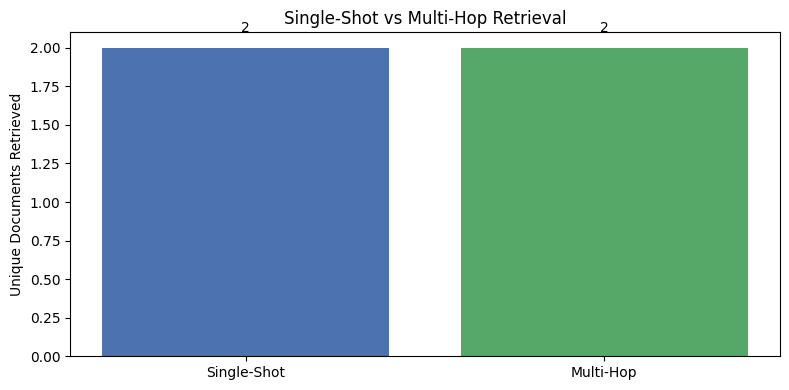

Single doc IDs: ['PG-002', 'RN-001']
Multi doc IDs:  ['PG-002', 'RN-001']
Multi-hop gain: +0 unique documents


In [8]:
hop = report['single_vs_multi_hop']
fig, ax = plt.subplots(figsize=(8, 4))
labels = ['Single-Shot', 'Multi-Hop']
counts = [hop['unique_docs_single'], hop['unique_docs_multi']]
ax.bar(labels, counts, color=['#4C72B0', '#55A868'])
ax.set_ylabel('Unique Documents Retrieved')
ax.set_title('Single-Shot vs Multi-Hop Retrieval')
for i, v in enumerate(counts):
    ax.text(i, v + 0.1, str(v), ha='center')
plt.tight_layout()
plt.show()
print(f"Single doc IDs: {hop['single_doc_ids']}")
print(f"Multi doc IDs:  {hop['multi_doc_ids']}")
print(f"Multi-hop gain: +{hop['multi_hop_gain']} unique documents")

## 6. Summary Dashboard

In [9]:
summary = pd.DataFrame({
    'Metric': [
        'Retrieval Hit Rate',
        'Citation Coverage',
        'Suitability Gate Precision',
        'Escalation Detection Rate',
        'Entitlement Filter Working',
        'Multi-Hop Doc Gain',
        'RAGAS Faithfulness',
        'Agent Scenario Pass Rate',
    ],
    'Value': [
        f"{report['retrieval']['retrieval_hit_rate']:.1%}",
        f"{report['citation_coverage']['citation_coverage']:.1%}",
        f"{report['suitability_gate']['suitability_precision']:.1%}",
        f"{report['escalation']['escalation_detection_rate']:.1%}",
        str(report['entitlement']['filter_working']),
        str(report['single_vs_multi_hop']['multi_hop_gain']),
        str(report.get('faithfulness', {}).get('faithfulness_score', 'n/a')),
        f"{report.get('agent_scenarios', {}).get('agent_pass_rate', 0):.1%}" if not report.get('agent_scenarios', {}).get('agent_eval_skipped') else 'skipped',
    ],
})
summary

,Metric,Value
0,Retrieval Hit Rate,85.7%
1,Citation Coverage,100.0%
2,Suitability Gate Precision,100.0%
3,Escalation Detection Rate,100.0%
4,Entitlement Filter Working,True
5,Multi-Hop Doc Gain,0


## 7. RAGAS Faithfulness (Groundedness)

In [ ]:
faith = report.get('faithfulness', {})
print(f"Faithfulness: {faith.get('faithfulness_score')}")
print(f"Method: {faith.get('method', 'n/a')}")
print(f"Samples: {faith.get('samples', 0)}")

## 8. End-to-End Agent Scenarios

In [ ]:
agent = report.get('agent_scenarios', {})
if agent.get('agent_eval_skipped'):
    print('Agent eval skipped:', agent.get('reason'))
else:
    print(f"Agent pass rate: {agent.get('agent_pass_rate', 0):.1%}")
    pd.DataFrame(agent.get('details', []))